# Assignment 8: Handwritten Digit Recognition using ANN

This notebook follows the assignment requirements.

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 25s 2us/step
First five records:


,label,0,1,2,3,4,5,6,7,8,...,774,775,776,777,778,779,780,781,782,783
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Shape: (60000, 785)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, label to 783
dtypes: int64(785)
memory usage: 359.3 MB
None
Missing values: 0


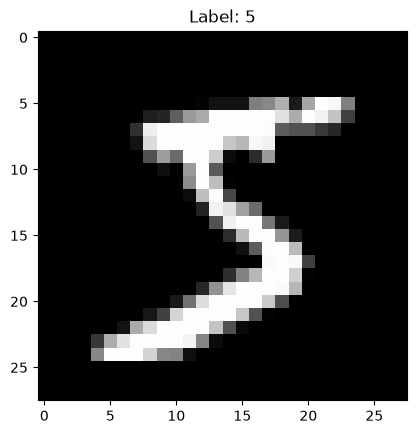

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8646 - loss: 0.4723 - val_accuracy: 0.9603 - val_loss: 0.1362
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9643 - loss: 0.1171 - val_accuracy: 0.9690 - val_loss: 0.0987
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9763 - loss: 0.0768 - val_accuracy: 0.9721 - val_loss: 0.0917
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9841 - loss: 0.0542 - val_accuracy: 0.9742 - val_loss: 0.0901
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9879 - loss: 0.0395 - val_accuracy: 0.9735 - val_loss: 0.0898
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9902 - loss: 0.0316 - val_accuracy: 0.9783 - val_loss: 0.0793
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9920 - loss: 0.0234 - val_accuracy: 0.9751 - val_loss: 0.0951
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9925 - loss: 0.0239 -

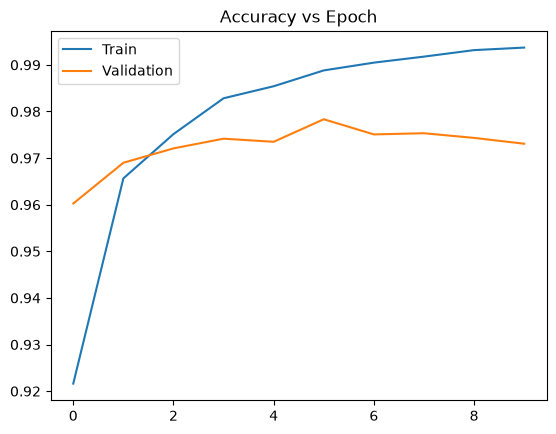

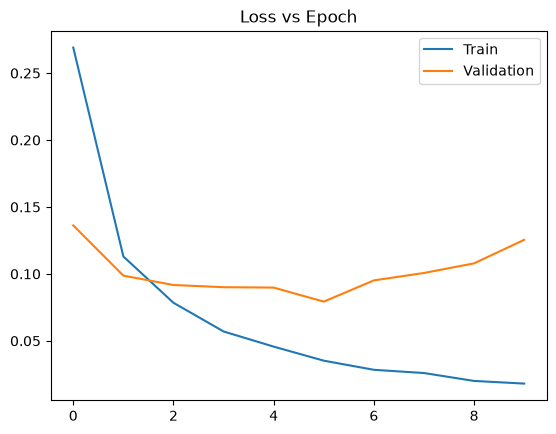


Observations:
1. Accuracy improves steadily across epochs.
2. Loss decreases with training.
3. ANN classifies most digits correctly.
4. Minor confusion exists between visually similar digits.


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
import os
from tensorflow.keras.datasets import mnist
if not os.path.exists('mnist_train.csv') or not os.path.exists('mnist_test.csv'):
    (x_train, y_train), (x_test, y_test) = mnist.load_data()

    train_df = pd.DataFrame(x_train.reshape(-1, 784))
    train_df.insert(0, 'label', y_train)
    test_df = pd.DataFrame(x_test.reshape(-1, 784))
    test_df.insert(0, 'label', y_test)

    train_df.to_csv('mnist_train.csv', index=False)
    test_df.to_csv('mnist_test.csv', index=False)
train_df = pd.read_csv('mnist_train.csv')
test_df = pd.read_csv('mnist_test.csv')

print("First five records:")
display(train_df.head())

print("Shape:", train_df.shape)
print(train_df.info())

print("Missing values:", train_df.isnull().sum().sum())

plt.imshow(train_df.iloc[0,1:].values.reshape(28,28), cmap='gray')
plt.title(f"Label: {train_df.iloc[0,0]}")
plt.show()

X = train_df.iloc[:,1:].values/255.0
y = train_df.iloc[:,0].values

X_train,X_val,y_train,y_val=train_test_split(X,y,test_size=0.2,random_state=42)

y_train=to_categorical(y_train,10)
y_val=to_categorical(y_val,10)

model=Sequential([
Dense(128,activation='relu',input_shape=(784,)),
Dense(64,activation='relu'),
Dense(10,activation='softmax')
])

model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])
history=model.fit(X_train,y_train,epochs=10,validation_data=(X_val,y_val))

X_test=test_df.iloc[:,1:].values/255.0
y_test=test_df.iloc[:,0].values
y_test_cat=to_categorical(y_test,10)

loss,acc=model.evaluate(X_test,y_test_cat)
print("Test Accuracy:",acc)

pred=np.argmax(model.predict(X_test),axis=1)

print(confusion_matrix(y_test,pred))
print(classification_report(y_test,pred))

plt.plot(history.history['accuracy'],label='Train')
plt.plot(history.history['val_accuracy'],label='Validation')
plt.legend(); plt.title('Accuracy vs Epoch')
plt.show()

plt.plot(history.history['loss'],label='Train')
plt.plot(history.history['val_loss'],label='Validation')
plt.legend(); plt.title('Loss vs Epoch')
plt.show()

print("\nObservations:")
print("1. Accuracy improves steadily across epochs.")
print("2. Loss decreases with training.")
print("3. ANN classifies most digits correctly.")
print("4. Minor confusion exists between visually similar digits.")



## Conclusion

The ANN successfully classifies handwritten digits using the MNIST dataset. Two hidden layers help the network learn increasingly complex image features, resulting in high classification accuracy. Deep learning performs better than many traditional machine learning methods because it automatically learns useful features from raw pixel values. However, ANN models require more computational resources and training time than simpler algorithms. Overall, this approach demonstrates the effectiveness of neural networks for image classification tasks.
